In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as skl

In [2]:
!pip install scikit-learn

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aryanmdev/world-gym-and-fitness-trends-20002026")

print("Path to dataset files:", path)

100%|██████████| 1.86M/1.86M [00:00<00:00, 149MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/aryanmdev/world-gym-and-fitness-trends-20002026/versions/1


In [10]:
print(path)

/root/.cache/kagglehub/datasets/aryanmdev/world-gym-and-fitness-trends-20002026/versions/1


In [11]:
import os
os.listdir(path)

['image.png', 'clean_gym_data.csv']

In [16]:
import pandas as pd
df=pd.read_csv("/root/.cache/kagglehub/datasets/aryanmdev/world-gym-and-fitness-trends-20002026/versions/1/clean_gym_data.csv")
df.head()

,country,year,region,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
0,Angola,2000,Africa,95521.0,0.3873,5731259.0,204.0,0.0059,0.5051,0.0470,563.7338,16194869.0,5.0,0.2219
1,Angola,2001,Africa,103840.0,0.3939,6230372.0,222.0,0.0062,0.5172,0.0496,533.5862,16747208.0,5.0,0.2192
2,Angola,2002,Africa,121093.0,0.4003,7265583.0,249.0,0.0070,0.5289,0.0522,999.0659,17327699.0,5.0,0.2164
3,Angola,2003,Africa,142783.0,0.4065,8566966.0,281.0,0.0080,0.5400,0.0548,1133.6633,17943712.0,5.0,0.2137
4,Angola,2004,Africa,179615.0,0.4124,10776918.0,325.0,0.0097,0.5504,0.0574,1451.4712,18600423.0,5.0,0.2110


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3564 entries, 0 to 3563
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   country                             3564 non-null   object 
 1   year                                3564 non-null   int64  
 2   region                              3564 non-null   object 
 3   gym_memberships                     3564 non-null   float64
 4   fitness_participation_rate          3564 non-null   float64
 5   total_health_club_revenue_usd       3564 non-null   float64
 6   number_of_gyms                      3564 non-null   float64
 7   gym_penetration_rate                3564 non-null   float64
 8   urban_population_percentage         3564 non-null   float64
 9   obesity_rate                        3564 non-null   float64
 10  gdp_per_capita_usd                  3564 non-null   float64
 11  population_total                    3564 no

In [18]:
df.describe()

,year,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
count,3564.000000,3.564000e+03,3564.000000,3.564000e+03,3564.000000,3564.000000,3564.000000,3564.000000,3564.000000,3.564000e+03,3564.000000,3564.000000
mean,2013.000000,2.376142e+06,0.397892,6.034040e+08,2076.547138,0.067213,0.610007,0.187892,15615.268427,5.185536e+07,14.371563,0.272071
std,7.789974,7.129730e+06,0.087345,2.981056e+09,5227.710072,0.057984,0.219071,0.104702,21272.389671,1.657860e+08,14.064816,0.118444
min,2000.000000,2.051000e+03,0.204700,1.648750e+05,3.000000,0.002300,0.116400,0.002800,109.593800,1.816850e+05,5.000000,0.027000
25%,2006.000000,1.628528e+05,0.333100,1.533129e+07,205.000000,0.019600,0.463475,0.102975,2011.057500,4.467102e+06,5.060000,0.188000
50%,2013.000000,5.108880e+05,0.399900,5.568824e+07,556.000000,0.052200,0.633950,0.196100,5830.212650,1.210349e+07,8.055000,0.250100
75%,2020.000000,1.560638e+06,0.453750,2.737641e+08,1580.750000,0.099500,0.784175,0.259400,21455.622900,3.803110e+07,17.792500,0.345025
max,2026.000000,1.027881e+08,0.675800,8.486183e+10,62233.000000,0.302200,1.000000,0.612400,137781.681700,1.450936e+09,90.920000,0.661400


In [22]:
df.isna().sum()

,0
country,0
year,0
region,0
gym_memberships,0
fitness_participation_rate,0
total_health_club_revenue_usd,0
number_of_gyms,0
gym_penetration_rate,0
urban_population_percentage,0
obesity_rate,0


In [23]:
numeric_df =df.select_dtypes('float64')
numeric_df.corr()

,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
gym_memberships,1.000000,0.143830,0.812254,0.977419,0.217177,0.156038,0.081549,0.181681,0.574954,0.202664,0.044836
fitness_participation_rate,0.143830,1.000000,0.150313,0.129816,0.568238,0.683772,0.175159,0.483447,-0.102323,0.476616,-0.318343
total_health_club_revenue_usd,0.812254,0.150313,1.000000,0.705429,0.300175,0.154874,0.151628,0.277418,0.228982,0.312515,0.037336
number_of_gyms,0.977419,0.129816,0.705429,1.000000,0.161257,0.128249,0.037421,0.122128,0.681149,0.138716,0.028693
gym_penetration_rate,0.217177,0.568238,0.300175,0.161257,1.000000,0.672900,0.493174,0.854559,-0.115408,0.862586,0.196956
urban_population_percentage,0.156038,0.683772,0.154874,0.128249,0.672900,1.000000,0.520865,0.577835,-0.104224,0.541599,0.457595
obesity_rate,0.081549,0.175159,0.151628,0.037421,0.493174,0.520865,1.000000,0.268480,-0.189827,0.268781,0.473558
gdp_per_capita_usd,0.181681,0.483447,0.277418,0.122128,0.854559,0.577835,0.268480,1.000000,-0.075418,0.989220,0.162179
population_total,0.574954,-0.102323,0.228982,0.681149,-0.115408,-0.104224,-0.189827,-0.075418,1.000000,-0.076666,0.023045
average_membership_cost_usd,0.202664,0.476616,0.312515,0.138716,0.862586,0.541599,0.268781,0.989220,-0.076666,1.000000,0.129678


<Axes: >

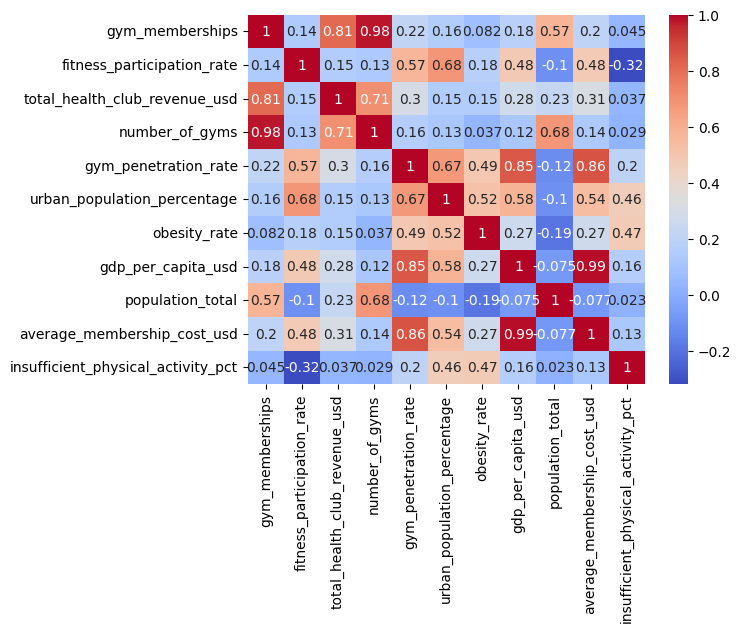

In [24]:
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')


<Axes: xlabel='urban_population_percentage', ylabel='fitness_participation_rate'>

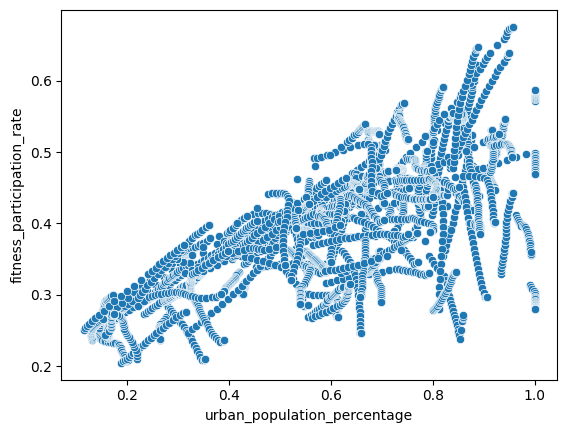

In [27]:
sns.scatterplot(data=df, x='urban_population_percentage', y='fitness_participation_rate')

<Axes: xlabel='urban_population_percentage', ylabel='fitness_participation_rate'>

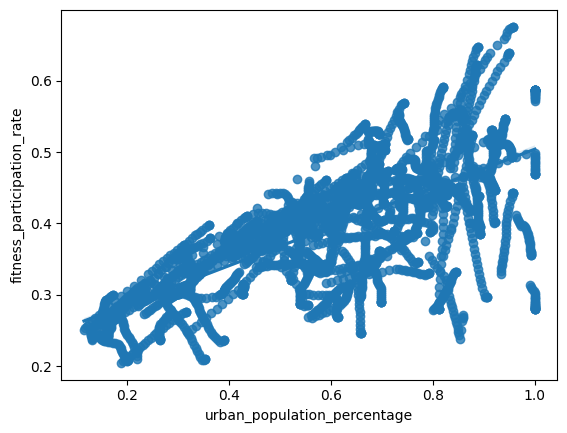

In [29]:
sns.regplot(data=df, x='urban_population_percentage', y='fitness_participation_rate')

<Axes: xlabel='fitness_participation_rate', ylabel='obesity_rate'>

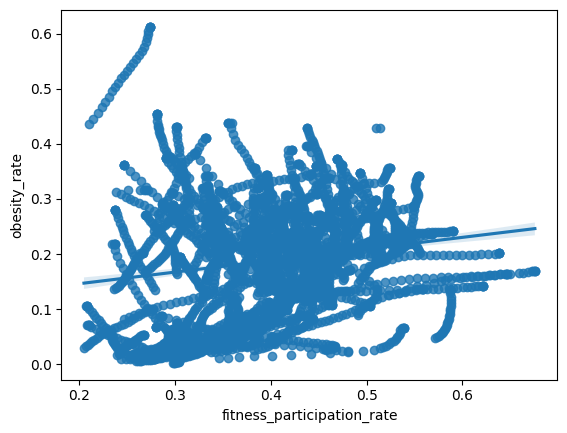

In [56]:
sns.regplot(data=df, x='fitness_participation_rate', y='obesity_rate')

<Axes: xlabel='urban_population_percentage', ylabel='obesity_rate'>

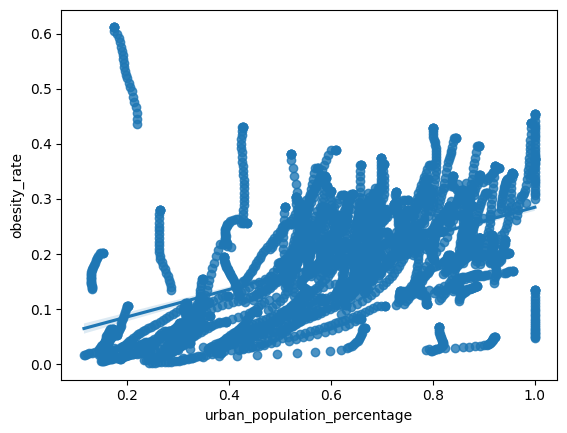

In [32]:
sns.regplot(data=df, x='urban_population_percentage', y='obesity_rate')

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
model=LinearRegression()


In [49]:
from sklearn.model_selection import train_test_split
x=df[['urban_population_percentage', 'fitness_participation_rate']]
y=df['obesity_rate']
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

model.fit(x_train, y_train)
d=model.predict(x_test)


In [50]:
print(d)

[0.21458217 0.18450226 0.18519088 0.13935743 0.09398596 0.19877947
 0.17415409 0.18870266 0.20706828 0.17878677 0.14981666 0.12094773
 0.15411815 0.1837587  0.09701974 0.21425755 0.16202832 0.07607319
 0.157659   0.14098636 0.28272723 0.18132946 0.24135054 0.19146033
 0.07721571 0.18063433 0.10883976 0.11507079 0.2504714  0.08178657
 0.21322058 0.09798975 0.32503902 0.16080554 0.08578292 0.2800931
 0.1468931  0.15323103 0.16469683 0.17037992 0.18961865 0.14622861
 0.15296255 0.19035456 0.22216286 0.33199065 0.35587084 0.1992778
 0.20431377 0.20259621 0.09695249 0.17630388 0.11453946 0.13043045
 0.19476591 0.29783711 0.15003176 0.21256421 0.27020579 0.24215976
 0.15638707 0.14938675 0.18157978 0.32306568 0.15630983 0.37267244
 0.23216252 0.27554179 0.2323306  0.27157427 0.21091371 0.1612445
 0.12094021 0.1566287  0.21698663 0.15448615 0.17636972 0.23998223
 0.18173274 0.12597051 0.12211859 0.18037523 0.14428422 0.14661987
 0.29761272 0.20162591 0.17513027 0.19161632 0.14756884 0.1980573

In [51]:
results=pd.DataFrame({'Actual':y_test, 'Predicted':d})
results.head()

,Actual,Predicted
2498,0.3087,0.214582
184,0.1704,0.184502
1850,0.2779,0.185191
1361,0.0373,0.139357
2857,0.0457,0.093986


In [53]:
model.score(x_test, y_test)


0.41428322668432427

Summary:The dataset captures global gym and fitness trends. Its markers included country, year, region, gym memberships, fitness participation rate, total health club revenue in usd, number of gyms, gym penetration rate, urban population percentage, obesity rate, gdp per capita in usd, population total, average membership cost in usd, and insufficient physical activity. Naturally, the amount of gym memberships was strongly correlated to the revenue generated as well as the number of gyms as the demand for memberships increases these markers. Interestingly the correlation matrix revealed that urban populations have a strong correlation to fitness participation as well as a moderate correlation to obesity. It was intriguing that urban populatons can simultaneously have a high fitness participation rate as well as a considerable obesity one. A linear regression model was introduced to predict how urban population and fitness rates can help predict obesity. However, the model score (~41%) was not truly remarkable.

Recommendations: As demonstrated by the data related to the urban population percentage, people can have significant participation in fitness spaces while also being classified as obese. This reveals that obesity is affected by a multitude of factors and that obesity rates, while influenced, are not directly proportional and dependent on fitness participation. Other factors that could perhaps be explored to explain the model's results are urban areas' access to fast food compared to their rural counterparts as well as how walkable urban areas are. Expanding the factors explored would support understanding of the various factors that can lead to obesity. Additionally, a comprehensive analysis could also even be of use in order to reduce obesity rates.